# EUROFER / F-M Steel Irradiated Microstructure — Density & Size Trends

Visualises the consolidated experimental database **`EuroferMicrostructure.xlsx`**
as **scatter trend plots**. For each microstructural quantity (defect density or
mean size) we draw **two separate figures**:

* **value vs irradiation temperature**, and
* **value vs dose** (log x).

Each data point is plotted as a **discrete marker** (no connecting lines), and the
**colour + symbol combination is unique to the source (reference)** the datum comes
from. A **legend listing the sources is placed underneath each figure** (outside the
axes), so the same source carries the same colour/symbol across every panel.
Densities use a log y-axis; mean sizes use a linear y-axis.

Panels: (1) neutron loop density, (2) neutron loop size, (3) neutron void/cavity
density, (4) radiation-induced precipitate number density, (5) ion-irradiation loop
density, (6) ion-irradiation void/cavity density, and (7) the ½⟨111⟩ vs ⟨100⟩ loop
size distributions (fraction vs diameter, 350 °C / 16 dpa).

In [1]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- global style: size-16 fonts ----
plt.rcParams.update({
    "font.size": 16, "axes.titlesize": 16, "axes.labelsize": 16,
    "xtick.labelsize": 14, "ytick.labelsize": 14, "figure.dpi": 110,
})

# ---- locate the consolidated workbook ----
CANDIDATES = ["../../input/EuroferMicrostructure.xlsx",
              "../input/EuroferMicrostructure.xlsx",
              "input/EuroferMicrostructure.xlsx",
              "EuroferMicrostructure.xlsx"]
XLSX = next((p for p in CANDIDATES if os.path.exists(p)), CANDIDATES[0])
print("Reading:", os.path.abspath(XLSX))

# ---- superscript handling --------------------------------------------------
# NOTE: superscripts 1/2/3 (¹²³) are Latin-1 (U+00B9/B2/B3) and lie OUTSIDE the
# Unicode superscript block U+2070-U+2079 (⁰⁴⁵⁶⁷⁸⁹⁻).  A naive class [⁰-⁹] thus
# silently MISSES ¹²³, so "~10²³" parsed to 10 and "7.4×10²³" to 7.4 — the cause
# of the spurious 7-10 precipitate "densities".  _SUP and _SUPCLS below cover both.
_SUP = {"⁰":"0","¹":"1","²":"2","³":"3","⁴":"4",
        "⁵":"5","⁶":"6","⁷":"7","⁸":"8","⁹":"9","⁻":"-"}
_SUPCLS = "⁰-⁹⁻¹²³"            # regex char-class body covering BOTH encodings
def _desuper(t):
    return "".join(_SUP.get(c, c) for c in t)

# ---- numeric parsers (data cells contain ~, <, >, ranges and superscripts) ----
def parse_num(x, geom=False):
    """Plain numbers / ranges (a-b) / '~x' / '<x' / '>x'. Range -> mean (or geom)."""
    if x is None:
        return np.nan
    if isinstance(x, (int, float)):
        return np.nan if (isinstance(x, float) and np.isnan(x)) else float(x)
    s = str(x).strip()
    if not s:
        return np.nan
    s = (s.replace("−", "-").replace("–", "-").replace("—", "-")
           .replace("≤", "").replace("≥", "").replace("~", "")
           .replace("<", "").replace(">", ""))
    s = re.sub(rf"[×x]\s*10\s*[{_SUPCLS}\^\-\d]*", "", s)   # strip sci-notation tails
    nums = [float(n) for n in re.findall(r"\d+\.?\d*", s) if n not in ("", ".")]
    if not nums:
        return np.nan
    if len(nums) == 1:
        return nums[0]
    a, b = nums[0], nums[1]
    if geom and a > 0 and b > 0:
        return (a * b) ** 0.5
    return (a + b) / 2.0

def parse_sci(x):
    """Absolute densities in m^-3 written as 7.4x10^23, ~10^23, ~10^22-10^23, etc.
       Ranges are reduced to their geometric mean."""
    if x is None:
        return np.nan
    if isinstance(x, (int, float)):
        return np.nan if (isinstance(x, float) and np.isnan(x)) else float(x)
    s = str(x)
    # all "(coeff)x10^exp" or bare "10^exp" tokens (handles both superscript encodings)
    vals = []
    for m in re.finditer(rf"(?:(\d+\.?\d*)\s*[×x]\s*)?10\s*([{_SUPCLS}\^\-]*\d*)", s):
        coeff, exp = m.group(1), m.group(2)
        exp = _desuper(exp).replace("^", "")
        if not exp:
            continue
        try:
            vals.append(float(coeff or 1.0) * 10 ** int(exp))
        except ValueError:
            continue
    if vals:
        if len(vals) >= 2 and all(v > 0 for v in vals):
            return float(np.exp(np.mean(np.log(vals))))   # geometric mean of range
        return vals[0]
    n = re.findall(r"\d+\.?\d*", s)
    return float(n[0]) if n else np.nan

# value parsers
pdens = lambda v: parse_num(v, geom=True)   # density in units of 1e22 m^-3
psize = lambda v: parse_num(v, geom=False)  # diameter in nm
pprec = parse_sci                           # precipitate density in m^-3 (absolute)

# ---- citation map: Density-workbook [CIT-##] -> "Author Year" ----
_ref = pd.read_excel(XLSX, sheet_name="References", header=None).iloc[2:]
def _short(a):
    a = str(a).replace(" et al.", "").replace(" et al", "")
    a = re.split(r"\s*[&/]\s*", a)[0]   # keep first author (before & or /)
    return a.strip()
def _yr(y):
    try:
        return str(int(float(y)))
    except (ValueError, TypeError):
        return str(y)
DEN_MAP = {}
for _, r in _ref.iterrows():
    dk = r.iloc[7]
    if isinstance(dk, str) and dk.strip().upper().startswith("CIT"):
        DEN_MAP[dk.strip()] = f"{_short(r.iloc[1])} {_yr(r.iloc[2])}"

# ---- generic loader ----
def load(sheet, mat, dose, temp, val, ref, valparser=pdens,
         data_start=3, irrcol=None, irr=None, refmap=None):
    raw = pd.read_excel(XLSX, sheet_name=sheet, header=None).iloc[data_start:]
    df = pd.DataFrame({
        "material": raw.iloc[:, mat].astype(str).str.strip(),
        "dose":     raw.iloc[:, dose].map(parse_num),
        "temp":     raw.iloc[:, temp].map(parse_num),
        "value":    raw.iloc[:, val].map(valparser),
        "ref":      raw.iloc[:, ref].astype(str).str.strip(),
    })
    if irrcol is not None and irr is not None:
        # match by leading word so "Neutron fission" is NOT caught by irr="Ion"
        col = raw.iloc[:, irrcol].astype(str).str.strip().str.lower()
        keep = col.str.startswith(irr.lower())
        df = df[keep.values]
    if refmap is not None:
        df["ref"] = df["ref"].map(
            lambda k: refmap.get(str(k).strip().strip("[]"), str(k).strip()))
    df = df[df["material"].str.lower() != "nan"]
    return df.dropna(subset=["dose", "temp", "value"]).reset_index(drop=True)

# ---- consistent (colour, marker) per data source ----
# Each source (reference) gets a unique colour AND symbol, kept stable across
# every figure so the same study reads the same everywhere. Both indices advance
# together (20 colours, 15 symbols), so neighbouring sources differ in colour and
# shape — distinguishable even where the tab20 palette has near-identical hues.
_PALETTE = list(plt.get_cmap("tab20").colors)          # 20 distinct colours
_MARKERS = ["o", "s", "^", "v", "D", "P", "X", "*",
            "<", ">", "h", "p", "d", "H", "8"]          # 15 symbols
_style_cache = {}
def source_style(src):
    """Return a unique, stable (colour, marker) pair for each source."""
    if src not in _style_cache:
        k = len(_style_cache)
        _style_cache[src] = (_PALETTE[k % len(_PALETTE)],
                             _MARKERS[k % len(_MARKERS)])
    return _style_cache[src]

def _fmt_cond(vals, unit):
    """Compact label for a source's complementary condition: a single value, or a
    'min–max' range when that source spans several (e.g. '16 dpa', '250–415 °C')."""
    v = sorted({float(x) for x in vals if pd.notna(x)})
    if not v:
        return ""
    def f(x):
        return str(int(round(x))) if abs(x - round(x)) < 1e-6 else f"{x:g}"
    return f"{f(v[0])} {unit}" if len(v) == 1 else f"{f(v[0])}–{f(v[-1])} {unit}"

def _scatter_by_source(ax, df, xcol, cond_col, cond_unit):
    """Scatter df[xcol] vs df['value'], one colour/symbol per source. No lines.
    Each legend entry is annotated with the source's complementary condition — the
    variable NOT on the x-axis: the dose on a vs-temperature figure, the
    temperature on a vs-dose figure (e.g. 'Gaganidze 2011  (16 dpa)')."""
    for src in sorted(df["ref"].unique()):
        s = df[df["ref"] == src]
        colour, marker = source_style(src)
        cond = _fmt_cond(s[cond_col], cond_unit)
        label = f"{src}  ({cond})" if cond else src
        ax.scatter(s[xcol], s["value"], color=colour, marker=marker, s=95,
                   edgecolors="k", linewidths=0.6, label=label, zorder=3)

def _legend_below(fig, ax, nsrc, ncol):
    """Place a source legend underneath the axes (outside the figure body)."""
    rows = -(-nsrc // ncol)                              # ceil division
    bottom = min(0.55, 0.12 + 0.05 * rows)               # reserve room for legend
    fig.tight_layout(rect=[0, bottom, 1, 1])
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, title="Data source (reference, condition)",
               loc="lower center", bbox_to_anchor=(0.5, 0.0), ncol=ncol,
               fontsize=9, title_fontsize=11, frameon=True,
               handletextpad=0.3, columnspacing=1.0)

def make_plots(df, value_label, title, logy=True, dens_scale=1.0):
    """Two SEPARATE scatter figures (no A/B pair, no connecting lines):
         (1) value vs irradiation temperature  (legend annotated with dose),
         (2) value vs dose (log x)             (legend annotated with temperature).
       Colour + symbol encode the data source; the source legend sits underneath
       each figure (outside the axes)."""
    df = df.copy()
    df["value"] = df["value"] * dens_scale
    nsrc = df["ref"].nunique()
    ncol = min(3, max(1, nsrc))                          # 3 cols: room for the condition tag

    # ---- (1) value vs temperature  (annotate legend with each source's dose) ----
    figT, axT = plt.subplots(figsize=(9, 6))
    _scatter_by_source(axT, df, "temp", "dose", "dpa")
    axT.set_xlabel(r"Irradiation temperature (°C)")
    axT.set_ylabel(value_label)
    if logy:
        axT.set_yscale("log")
    axT.set_title(f"{title} — vs temperature")
    axT.grid(alpha=0.25, linestyle=":")
    _legend_below(figT, axT, nsrc, ncol)

    # ---- (2) value vs dose  (annotate legend with each source's temperature) ----
    figD, axD = plt.subplots(figsize=(9, 6))
    _scatter_by_source(axD, df, "dose", "temp", "°C")
    axD.set_xscale("log")
    axD.set_xlabel("Dose (dpa)")
    axD.set_ylabel(value_label)
    if logy:
        axD.set_yscale("log")
    axD.set_title(f"{title} — vs dose")
    axD.grid(alpha=0.25, linestyle=":")
    _legend_below(figD, axD, nsrc, ncol)

    print(f"{title}: {len(df)} points, {nsrc} sources")
    return (figT, axT), (figD, axD)

Reading: D:\GitHub\RadCluster\RadCluster_2_1\input\EuroferMicrostructure.xlsx


### Approximate trend lines

Each scatter figure also carries a few **smooth, low-order trend curves** grouped by
the *complementary* variable:

* on a **value-vs-temperature** figure the bands are approximate **dose** ranges, and
* on a **value-vs-dose** figure the bands are approximate **temperature** ranges.

The trends are degree-1/2 polynomial fits taken in **log-y** (and **log-x** on the dose
axis), so the lines are simple smooth guides — dotted / dashed / dash-dot per band, no
interpolation squiggles. The number of bands adapts to how many points a panel has
(1 band for sparse panels, up to 3). Set `trends=False` in `make_plots(...)` to disable.

In [2]:
# ---- approximate trend lines -------------------------------------------------
# Overlay a few smooth, low-order trend curves on each scatter figure, grouped by
# the *complementary* variable (dose bands on a vs-temperature plot; temperature
# bands on a vs-dose plot). Fits are degree-1/2 polynomials taken in log-y (and
# log-x on the dose axis), so the curves are smooth guides — not point-to-point
# squiggles. Trend lines carry the label "_nolegend_" so they stay out of the
# source legend underneath; their own band legend sits inside the axes.

def _fmt_band(x):
    return str(int(round(x))) if abs(x - round(x)) < 1e-6 else f"{x:g}"

def _add_trends(ax, df, xcol, band_col, band_unit, band_name,
                logx=False, logy=True, nbands=None, deg_max=2, min_pts=3):
    """Draw up to `nbands` smooth trend curves, one per quantile band of band_col."""
    d = df[[xcol, "value", band_col]].replace([np.inf, -np.inf], np.nan).dropna()
    if logy:
        d = d[d["value"] > 0]
    if len(d) < min_pts + 1:
        return
    if nbands is None:                                   # adapt to sample size
        nbands = 1 if len(d) < 8 else (2 if len(d) < 16 else 3)
    edges = np.unique(np.quantile(d[band_col].to_numpy(float),
                                  np.linspace(0, 1, nbands + 1)))
    if len(edges) < 2:
        return
    styles = ["dotted", "dashed", "dashdot"]
    cmap = plt.get_cmap("plasma")
    nb = len(edges) - 1
    handles, labels = [], []
    for bi in range(nb):
        lo, hi = edges[bi], edges[bi + 1]
        upper = (d[band_col] <= hi) if bi == nb - 1 else (d[band_col] < hi)
        s = d[(d[band_col] >= lo) & upper]
        x = s[xcol].to_numpy(float)
        X = np.log10(x) if logx else x
        Y = np.log10(s["value"].to_numpy(float)) if logy else s["value"].to_numpy(float)
        nuq = len(np.unique(np.round(X, 6)))
        if len(s) < min_pts or nuq < 2:                  # too few / no x-spread
            continue
        deg = min(deg_max, nuq - 1, 1 if len(s) < 6 else 2)
        coef = np.polyfit(X, Y, deg)
        xx = np.linspace(X.min(), X.max(), 120)          # span only this band's x-range
        yy = np.polyval(coef, xx)
        xp = 10 ** xx if logx else xx
        yp = 10 ** yy if logy else yy
        colour = cmap(0.12 + 0.72 * (bi / max(1, nb - 1)))
        h, = ax.plot(xp, yp, linestyle=styles[bi % len(styles)], color=colour,
                     lw=2.4, alpha=0.95, zorder=2, label="_nolegend_")
        handles.append(h)
        labels.append(f"≈ {_fmt_band(lo)}–{_fmt_band(hi)} {band_unit}")
    if handles:
        leg = ax.legend(handles, labels, title=f"approx. {band_name}",
                        loc="best", fontsize=9, title_fontsize=9,
                        framealpha=0.9, handlelength=2.6)
        ax.add_artist(leg)


def make_plots(df, value_label, title, logy=True, dens_scale=1.0, trends=True):
    """Two SEPARATE scatter figures (no connecting lines), each with smooth
    approximate trend curves overlaid:
         (1) value vs temperature  — trend bands by approximate DOSE,
         (2) value vs dose (log x) — trend bands by approximate TEMPERATURE.
    Colour + symbol encode the data source (legend underneath); the trend bands
    get their own small legend inside the axes."""
    df = df.copy()
    df["value"] = df["value"] * dens_scale
    nsrc = df["ref"].nunique()
    ncol = min(3, max(1, nsrc))

    # ---- (1) value vs temperature  (trend bands = approximate dose) ----
    figT, axT = plt.subplots(figsize=(9, 6))
    _scatter_by_source(axT, df, "temp", "dose", "dpa")
    if trends:
        _add_trends(axT, df, "temp", "dose", "dpa", "dose band",
                    logx=False, logy=logy)
    axT.set_xlabel(r"Irradiation temperature (°C)")
    axT.set_ylabel(value_label)
    if logy:
        axT.set_yscale("log")
    axT.set_title(f"{title} — vs temperature")
    axT.grid(alpha=0.25, linestyle=":")
    _legend_below(figT, axT, nsrc, ncol)

    # ---- (2) value vs dose  (trend bands = approximate temperature) ----
    figD, axD = plt.subplots(figsize=(9, 6))
    _scatter_by_source(axD, df, "dose", "temp", "°C")
    if trends:
        _add_trends(axD, df, "dose", "temp", "°C", "temperature band",
                    logx=True, logy=logy)
    axD.set_xscale("log")
    axD.set_xlabel("Dose (dpa)")
    axD.set_ylabel(value_label)
    if logy:
        axD.set_yscale("log")
    axD.set_title(f"{title} — vs dose")
    axD.grid(alpha=0.25, linestyle=":")
    _legend_below(figD, axD, nsrc, ncol)

    print(f"{title}: {len(df)} points, {nsrc} sources")
    return (figT, axT), (figD, axD)

## (1) Neutron irradiation — dislocation-loop number density
Source sheet `Loops_DenSize` (rows with `Irrad. Type = Neutron*`). Density is reported in units of $10^{22}\,$m$^{-3}$ and rescaled to absolute m$^{-3}$. Two scatter figures — loop density **vs temperature** and **vs dose** (log x) — with a unique colour/symbol per source and the source legend underneath.

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.


...

findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['DejaVu Sans Mono'] not found. Falling back to DejaVu Sans.


findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


Neutron — dislocation-loop density: 18 points, 10 sources


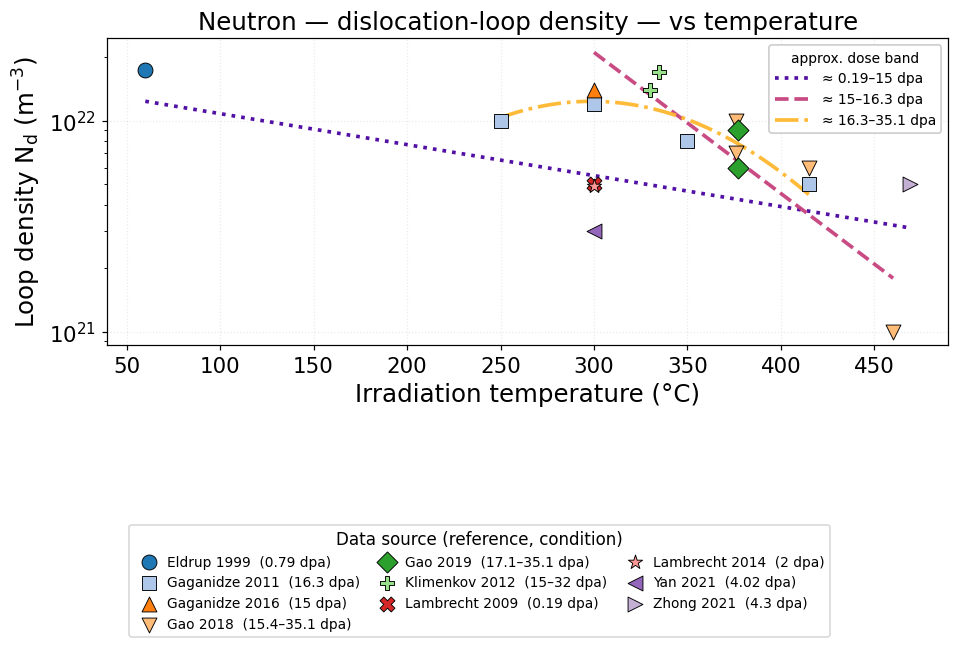

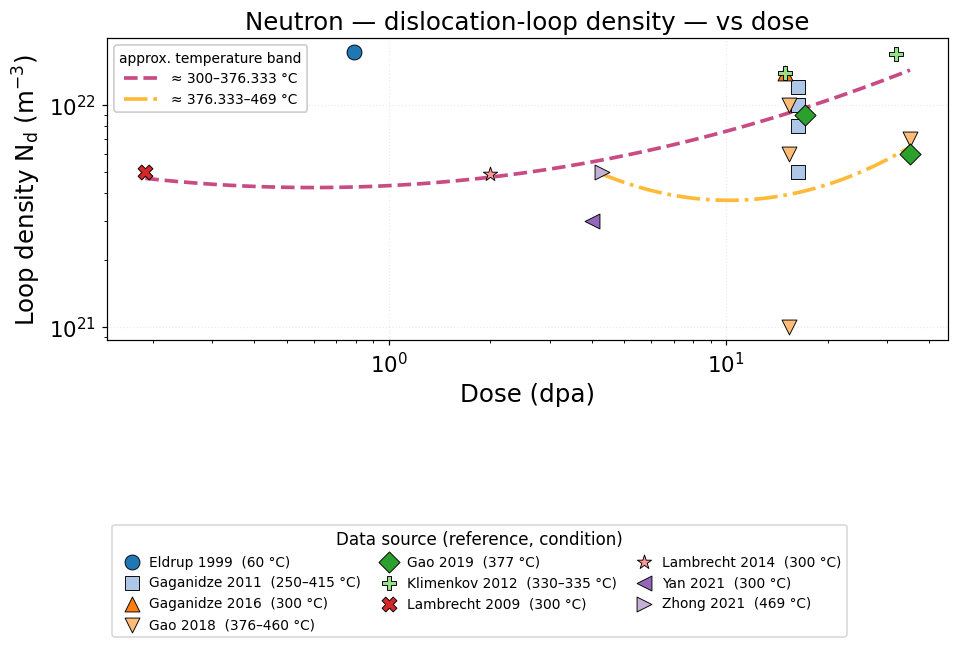

In [3]:
df = load("Loops_DenSize", mat=0, dose=7, temp=8, val=10, ref=19,
          valparser=pdens, irrcol=5, irr="Neutron", refmap=DEN_MAP)
make_plots(df, r"Loop density $N_d$ (m$^{-3}$)",
           "Neutron — dislocation-loop density",
           logy=True, dens_scale=1e22)
plt.show()

## (2) Neutron irradiation — mean dislocation-loop diameter
Same conditions as panel (1), but the plotted quantity is the **mean loop diameter** (nm) on a linear y-axis. Two scatter figures — mean diameter **vs temperature** and **vs dose** — coloured/symboled by source with the source legend underneath.

Neutron — mean loop diameter: 18 points, 10 sources


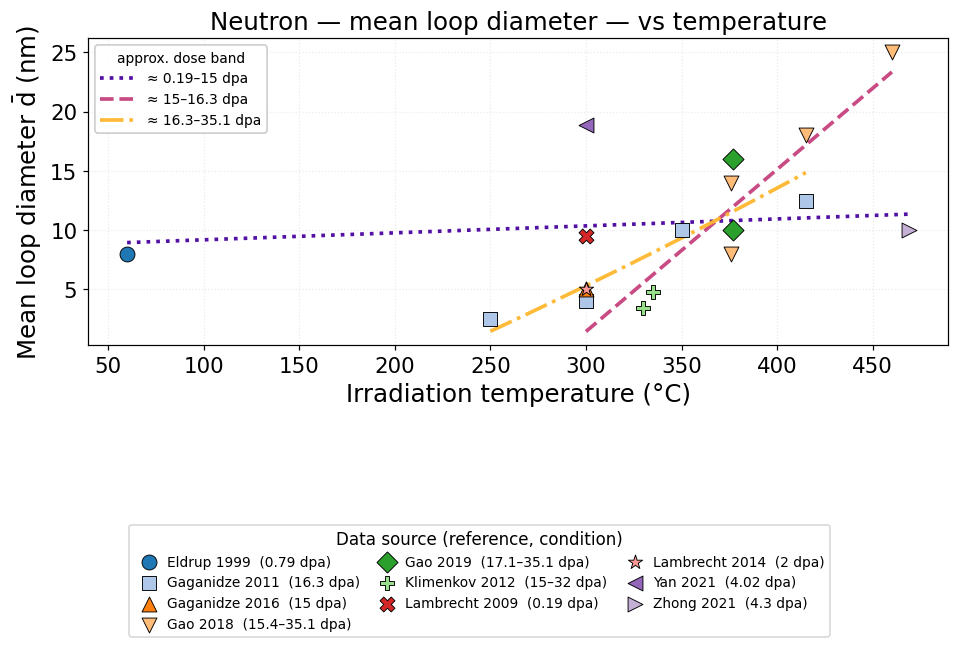

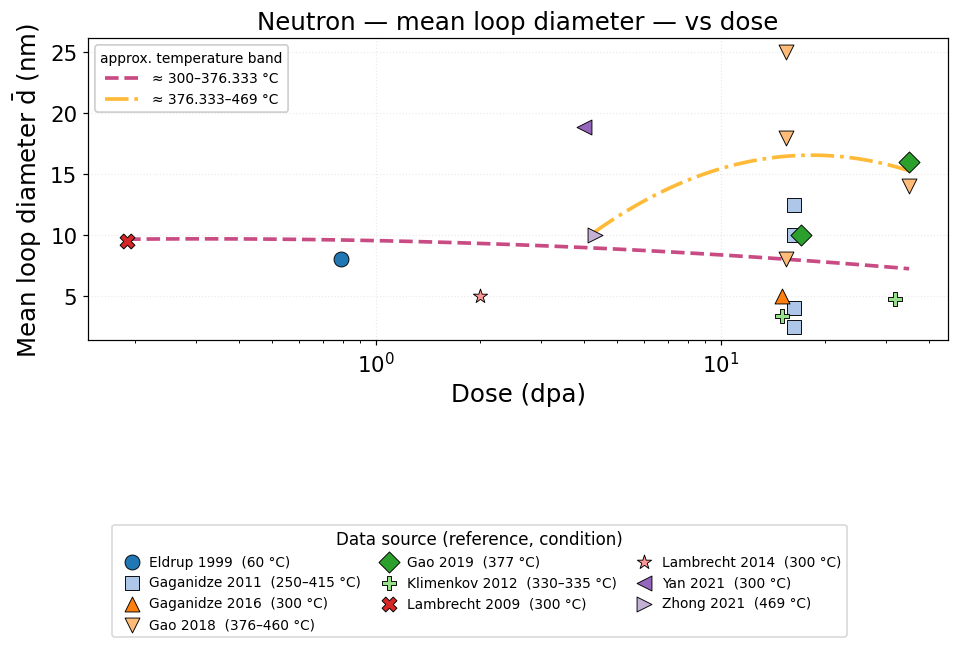

In [4]:
df = load("Loops_DenSize", mat=0, dose=7, temp=8, val=15, ref=19,
          valparser=psize, irrcol=5, irr="Neutron", refmap=DEN_MAP)
make_plots(df, r"Mean loop diameter $\bar d$ (nm)",
           "Neutron — mean loop diameter",
           logy=False)
plt.show()

## (3) Neutron irradiation — void / cavity number density
Source sheet `Voids_DenSize` (total cavity density, $10^{22}\,$m$^{-3}$). Below ~415 °C the population is unimodal (He-stabilised bubbles); a bimodal bubble+void structure develops at higher dose/temperature. Two scatter figures — cavity density **vs temperature** and **vs dose** — coloured/symboled by source with the source legend underneath.

Neutron — void / cavity density: 8 points, 6 sources


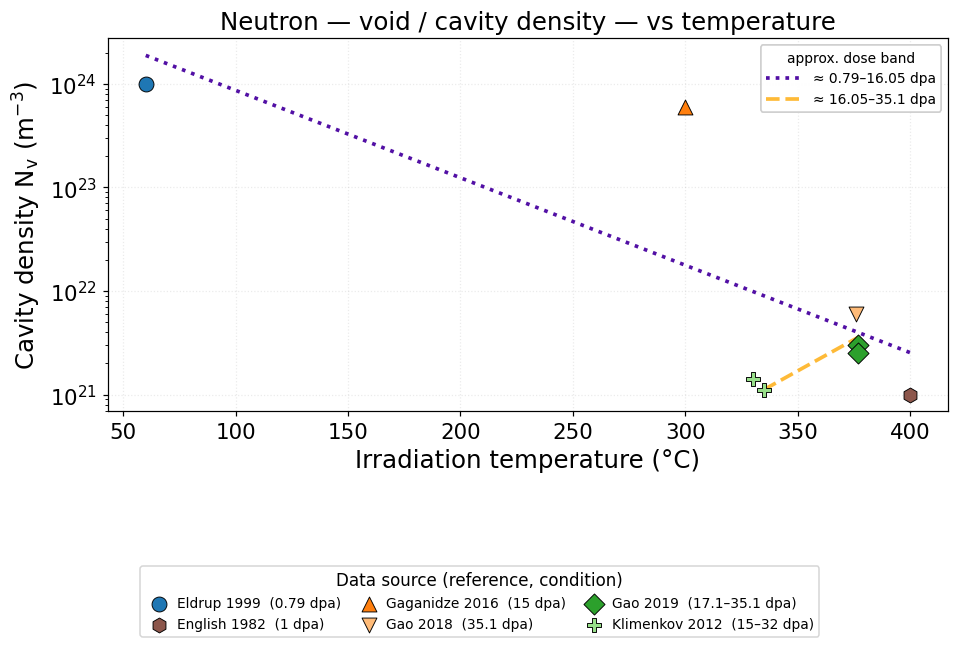

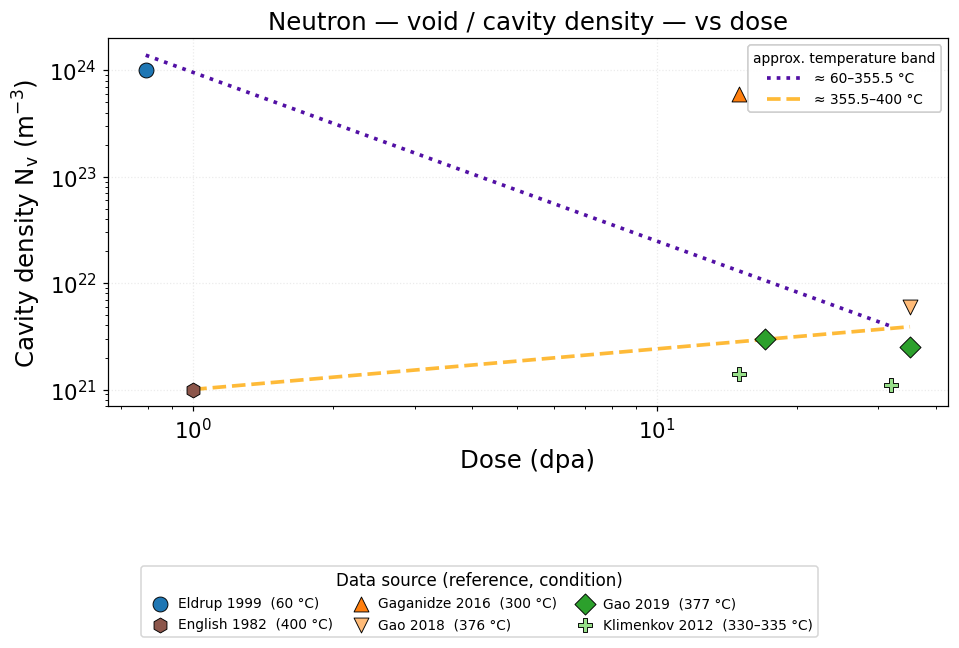

In [5]:
df = load("Voids_DenSize", mat=0, dose=7, temp=8, val=10, ref=20,
          valparser=pdens, irrcol=5, irr="Neutron", refmap=DEN_MAP)
make_plots(df, r"Cavity density $N_v$ (m$^{-3}$)",
           "Neutron — void / cavity density",
           logy=True, dens_scale=1e22)
plt.show()

## (4) Neutron irradiation — radiation-induced precipitate number density
Source sheet `N_Precipitates` (number density already in m$^{-3}$). Phases include α′ (Cr-rich bcc), G-phase (Mn/Ni/Si), MX (TaC, VN), M$_{23}$C$_6$ and Si-rich clusters; the reference column already carries author–year labels. Two scatter figures — precipitate density **vs temperature** and **vs dose** — coloured/symboled by source with the source legend underneath.

Neutron — precipitate number density: 6 points, 5 sources


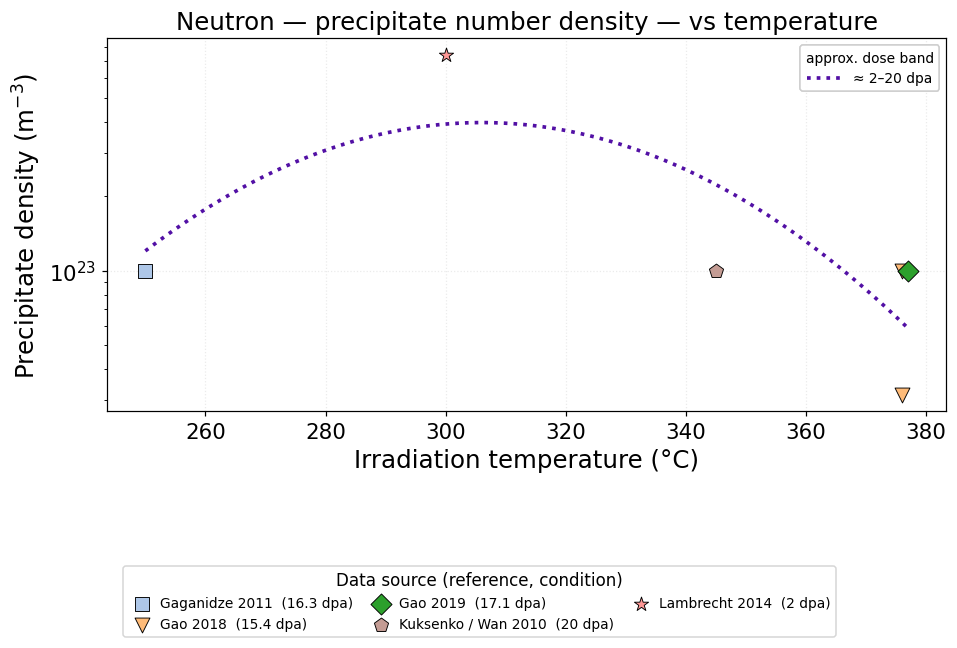

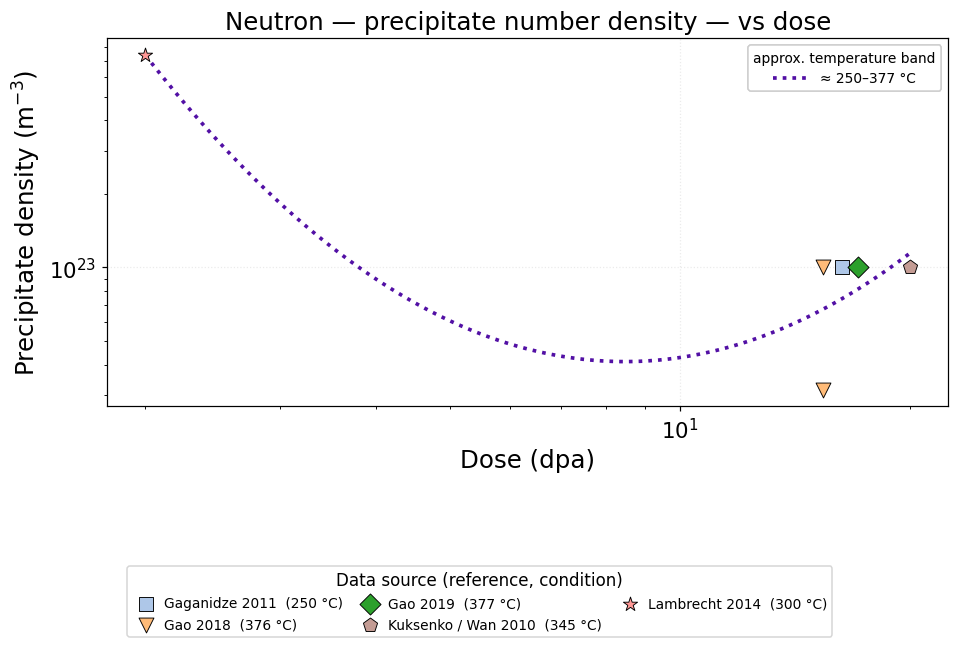

In [6]:
df = load("N_Precipitates", mat=0, dose=6, temp=7, val=11, ref=15,
          valparser=pprec, refmap=None)
make_plots(df, r"Precipitate density (m$^{-3}$)",
           "Neutron — precipitate number density",
           logy=True, dens_scale=1.0)
plt.show()

## (5) Ion irradiation — dislocation-loop number density
Source sheet `Loops_DenSize` (rows with `Irrad. Type = Ion*`): self-ion, dual-ion and in-situ Kr data. Note the much higher loop densities reached under self-ion irradiation (e.g. pure Fe, Fe-9Cr) and the ~+60–70 °C temperature shift relative to neutron data. Two scatter figures — loop density **vs temperature** and **vs dose** — coloured/symboled by source with the source legend underneath.

Ion — dislocation-loop density: 8 points, 7 sources


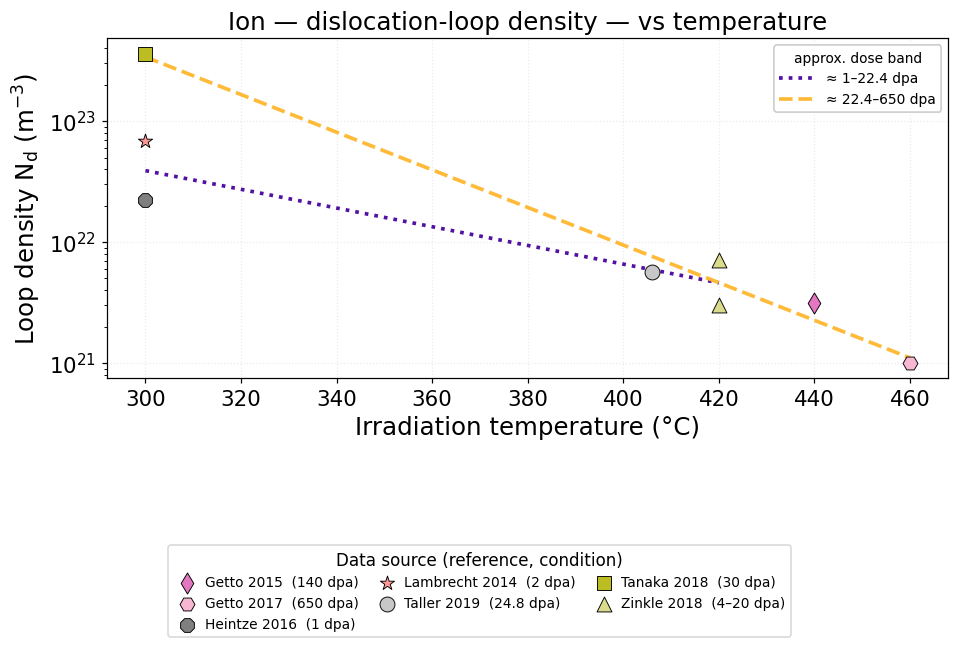

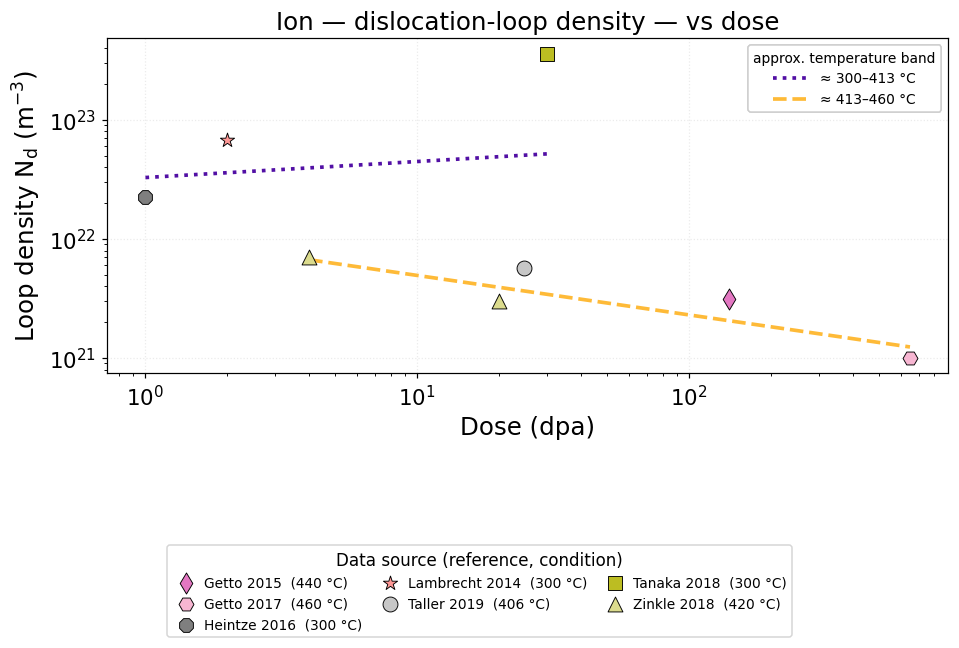

In [7]:
df = load("Loops_DenSize", mat=0, dose=7, temp=8, val=10, ref=19,
          valparser=pdens, irrcol=5, irr="Ion", refmap=DEN_MAP)
make_plots(df, r"Loop density $N_d$ (m$^{-3}$)",
           "Ion — dislocation-loop density",
           logy=True, dens_scale=1e22)
plt.show()

## (6) Ion irradiation — void / cavity number density
Source sheet `Voids_DenSize` (rows with `Irrad. Type = Ion*`): dual-ion T91/F82H and high-dose self-ion HT9. Peak swelling (bimodal cavities) occurs near 450–470 °C. Two scatter figures — cavity density **vs temperature** and **vs dose** — coloured/symboled by source with the source legend underneath.

Ion — void / cavity density: 5 points, 5 sources


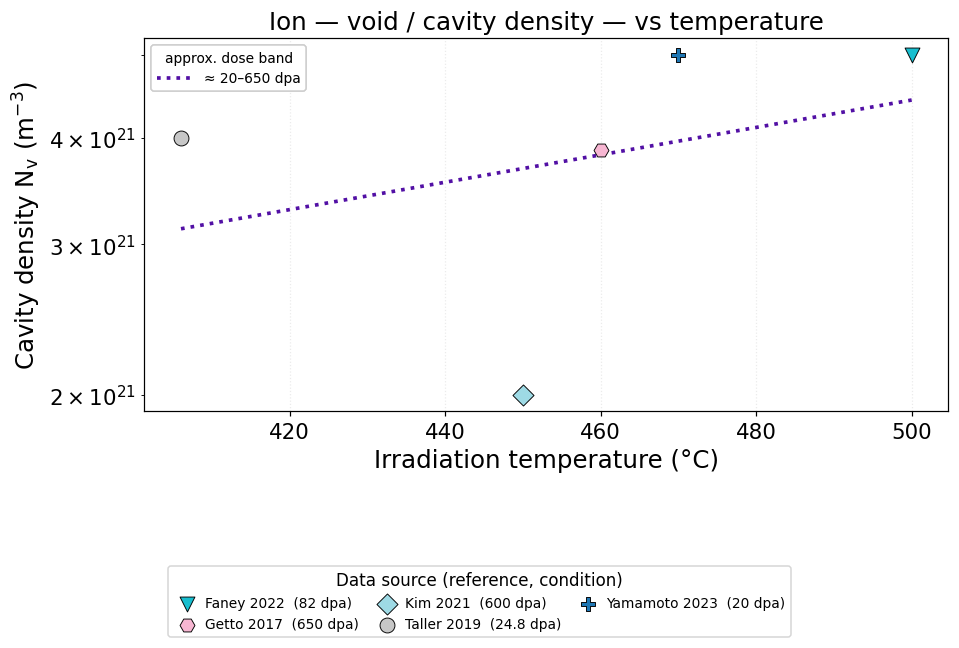

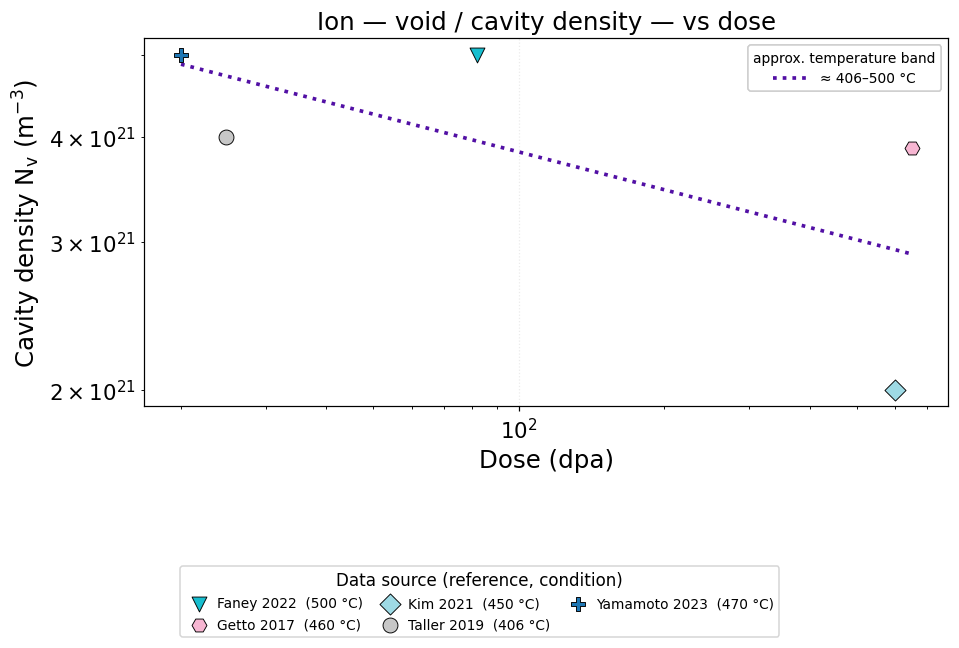

In [8]:
df = load("Voids_DenSize", mat=0, dose=7, temp=8, val=10, ref=20,
          valparser=pdens, irrcol=5, irr="Ion", refmap=DEN_MAP)
make_plots(df, r"Cavity density $N_v$ (m$^{-3}$)",
           "Ion — void / cavity density",
           logy=True, dens_scale=1e22)
plt.show()

## (7) ½⟨111⟩ vs ⟨100⟩ loop size distributions
Source sheet `Burgers_111_Frac`, condition `350C_16dpa` — the one condition resolved into separate Burgers-vector populations. The two distributions are overlaid as **discrete markers** (loop fraction in % vs loop diameter, nm): one series for ⟨100⟩ loops and one for ½⟨111⟩ loops. The ½⟨111⟩ population dominates the small-diameter (black-dot) end, while ⟨100⟩ loops carry the larger sizes — the classic ½⟨111⟩→⟨100⟩ size/temperature crossover in F-M steels.

Lognormal fits  f(D) = A/(D·σ·√(2π))·exp[-(ln D - μ)²/(2σ²)]   [% per nm]

$\langle 100\rangle$ loops:
   f(D) = 511.7/(D·0.439·√(2π))·exp[-(ln D - 2.834)²/(2·0.439²)]
          A = 511.70 %·nm,  μ = 2.834,  σ = 0.439
          median D = e^μ = 17.01 nm,  mode D = e^(μ-σ²) = 14.03 nm,  geom. σ = e^σ = 1.55

$\frac{1}{2}\langle 111\rangle$ loops:
   f(D) = 426.9/(D·0.418·√(2π))·exp[-(ln D - 3.173)²/(2·0.418²)]
          A = 426.94 %·nm,  μ = 3.173,  σ = 0.418
          median D = e^μ = 23.89 nm,  mode D = e^(μ-σ²) = 20.06 nm,  geom. σ = e^σ = 1.52



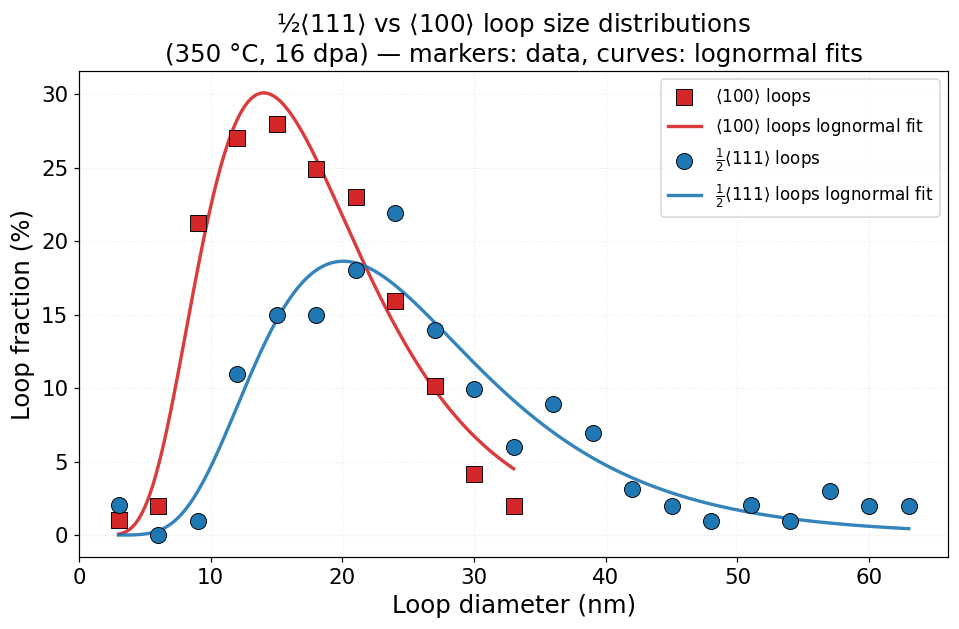

In [9]:
# ½<111> vs <100> loop size distributions for the 350 °C / 16 dpa condition.
# Burgers_111_Frac columns (0-indexed): 12/13 = <100> diameter/fraction,
#                                       15/16 = ½<111> diameter/fraction.
# Each population is also fitted with a LOGNORMAL number-fraction distribution
#   f(D) = A / (D·σ·√(2π)) · exp[ -(ln D - μ)² / (2σ²) ]   [% per nm]
# and the fitted equation is printed below the figure.
from scipy.optimize import curve_fit

braw = pd.read_excel(XLSX, sheet_name="Burgers_111_Frac", header=None).iloc[2:]
d100 = pd.to_numeric(braw.iloc[:, 12], errors="coerce")
f100 = pd.to_numeric(braw.iloc[:, 13], errors="coerce")
d111 = pd.to_numeric(braw.iloc[:, 15], errors="coerce")
f111 = pd.to_numeric(braw.iloc[:, 16], errors="coerce")
m100 = d100.notna() & f100.notna()
m111 = d111.notna() & f111.notna()


def _lognormal(D, A, mu, sig):
    """Lognormal number-fraction density (% per nm)."""
    return A / (D * sig * np.sqrt(2 * np.pi)) * np.exp(-(np.log(D) - mu) ** 2 / (2 * sig ** 2))


def fit_lognormal(D, f):
    """Least-squares lognormal fit of fraction f (%) vs diameter D (nm).
    Returns (A, mu, sig); seeds μ/σ from the fraction-weighted log-diameter moments."""
    D = np.asarray(D, float); f = np.asarray(f, float)
    g = (D > 0) & np.isfinite(f) & (f >= 0)
    D, f = D[g], f[g]
    w = f / f.sum() if f.sum() > 0 else np.ones_like(f) / len(f)
    mu0 = float(np.sum(w * np.log(D)))
    sig0 = float(np.sqrt(max(np.sum(w * (np.log(D) - mu0) ** 2), 1e-2)))
    A0 = float(f.sum() * np.median(np.diff(np.unique(D))))   # area ≈ Σf · bin width
    p, _ = curve_fit(_lognormal, D, f, p0=[A0, mu0, sig0], maxfev=20000)
    A, mu, sig = p
    return A, mu, abs(sig)


fig, ax = plt.subplots(figsize=(9, 6))
series = [
    (d100[m100].to_numpy(), f100[m100].to_numpy(),
     "#d62728", "s", r"$\langle 100\rangle$ loops"),
    (d111[m111].to_numpy(), f111[m111].to_numpy(),
     "#1f77b4", "o", r"$\frac{1}{2}\langle 111\rangle$ loops"),
]
print("Lognormal fits  f(D) = A/(D·σ·√(2π))·exp[-(ln D - μ)²/(2σ²)]   [% per nm]\n")
for D, f, colour, marker, lab in series:
    ax.scatter(D, f, color=colour, marker=marker, s=110,
               edgecolors="k", linewidths=0.6, label=lab, zorder=3)
    A, mu, sig = fit_lognormal(D, f)
    Dg = np.linspace(max(D.min(), 0.5), D.max(), 300)
    ax.plot(Dg, _lognormal(Dg, A, mu, sig), color=colour, lw=2.2,
            alpha=0.9, zorder=2, label=f"{lab} lognormal fit")
    med = np.exp(mu)               # median diameter (nm)
    mode = np.exp(mu - sig ** 2)   # modal diameter (nm)
    print(f"{lab}:")
    print(f"   f(D) = {A:.1f}/(D·{sig:.3f}·√(2π))·exp[-(ln D - {mu:.3f})²/(2·{sig:.3f}²)]")
    print(f"          A = {A:.2f} %·nm,  μ = {mu:.3f},  σ = {sig:.3f}")
    print(f"          median D = e^μ = {med:.2f} nm,  mode D = e^(μ-σ²) = {mode:.2f} nm,"
          f"  geom. σ = e^σ = {np.exp(sig):.2f}\n")

ax.set_xlabel("Loop diameter (nm)")
ax.set_ylabel("Loop fraction (%)")
ax.set_title(r"½$\langle 111\rangle$ vs $\langle 100\rangle$ loop size distributions"
             "\n(350 °C, 16 dpa) — markers: data, curves: lognormal fits")
ax.grid(alpha=0.25, linestyle=":")
ax.legend(fontsize=11, frameon=True)
fig.tight_layout()
plt.show()

## (8) Total microstructure — neutron + temperature-shifted ion data

The ion-irradiation data are **shifted down in temperature by 60 °C** and then **merged with
the neutron data** to give a single combined population. The −60 °C shift is the standard
dose-rate / temperature-shift correction: because ion beams damage at a far higher rate than
neutrons, an ion irradiation produces an equivalent microstructure at a *higher* nominal
temperature, so the ion points must move down on a shared temperature axis to be compared
with neutron data.

For each quantity that exists under both irradiation types — **loop density, loop size, and
void/cavity density** — we then repeat exactly the same two scatter figures (value vs
temperature, value vs dose, log axes, colour/symbol per source, source legend underneath,
smooth trend bands) used for the pure-neutron panels above. Precipitate density is neutron-only
and therefore unchanged from panel (4).

In [10]:
# ---- combine neutron + temperature-shifted ion data -------------------------
# Ion-irradiation data are shifted DOWN in temperature by 60 °C before merging
# with the neutron data. (The shift is the usual "temperature-shift" correction
# for the much higher displacement rate of ion beams: ion irradiation reaches an
# equivalent microstructure at a higher nominal temperature than neutrons, so to
# overlay the two on a common temperature axis the ion points move down ~60 °C.)
# Same sheet columns / parsers as the per-type panels above.
def load_total(sheet, val, ref, valparser, tshift=-60.0):
    """Neutron + ion data merged, with the ION temperatures shifted by `tshift` °C."""
    n = load(sheet, mat=0, dose=7, temp=8, val=val, ref=ref,
             valparser=valparser, irrcol=5, irr="Neutron", refmap=DEN_MAP)
    i = load(sheet, mat=0, dose=7, temp=8, val=val, ref=ref,
             valparser=valparser, irrcol=5, irr="Ion", refmap=DEN_MAP).copy()
    i["temp"] = i["temp"] + tshift          # shift ion data down in temperature
    out = pd.concat([n, i], ignore_index=True)
    print(f"{sheet}: {len(n)} neutron + {len(i)} ion (shifted {tshift:+.0f} °C) "
          f"= {len(out)} total points")
    return out

### (8a) Total — dislocation-loop number density
Neutron `Loops_DenSize` data plus the ion-irradiation loop data shifted **−60 °C**, same two scatter figures (vs temperature, vs dose).

Loops_DenSize: 18 neutron + 8 ion (shifted -60 °C) = 26 total points


Total (neutron + shifted ion) — dislocation-loop density: 26 points, 16 sources


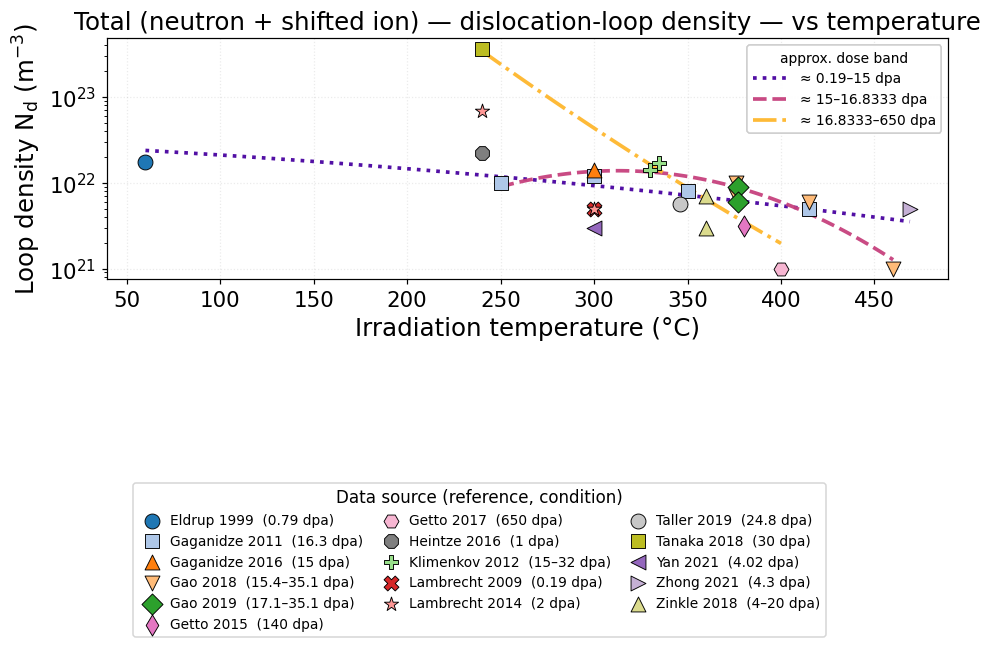

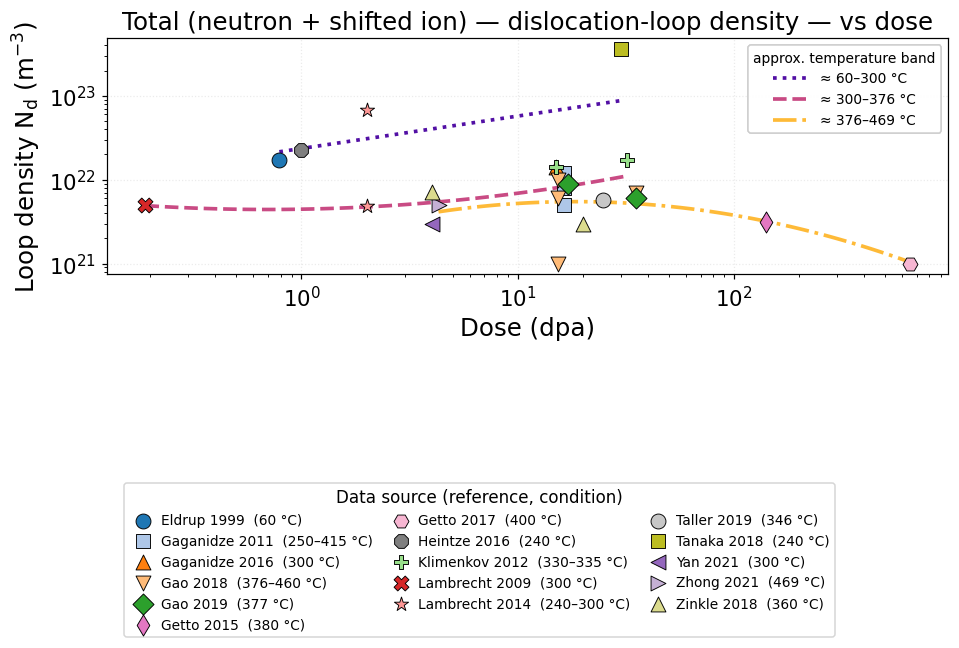

In [11]:
df = load_total("Loops_DenSize", val=10, ref=19, valparser=pdens)
make_plots(df, r"Loop density $N_d$ (m$^{-3}$)",
           "Total (neutron + shifted ion) — dislocation-loop density",
           logy=True, dens_scale=1e22)
plt.show()

### (8b) Total — mean dislocation-loop diameter
Neutron loop diameters plus the ion-irradiation loop diameters shifted **−60 °C** (linear y-axis), same two scatter figures.

Loops_DenSize: 18 neutron + 8 ion (shifted -60 °C) = 26 total points


Total (neutron + shifted ion) — mean loop diameter: 26 points, 16 sources


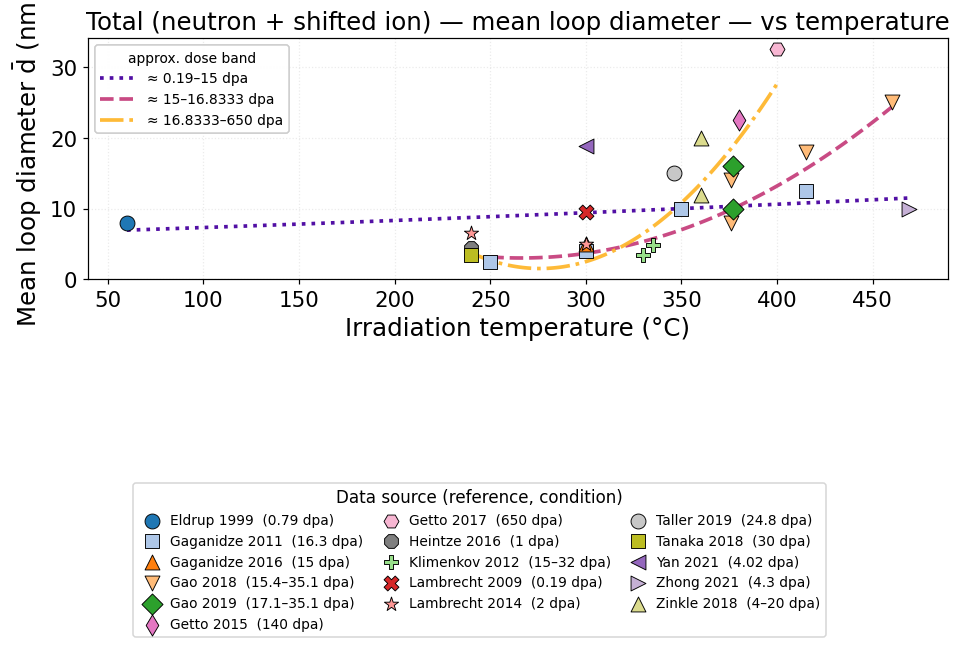

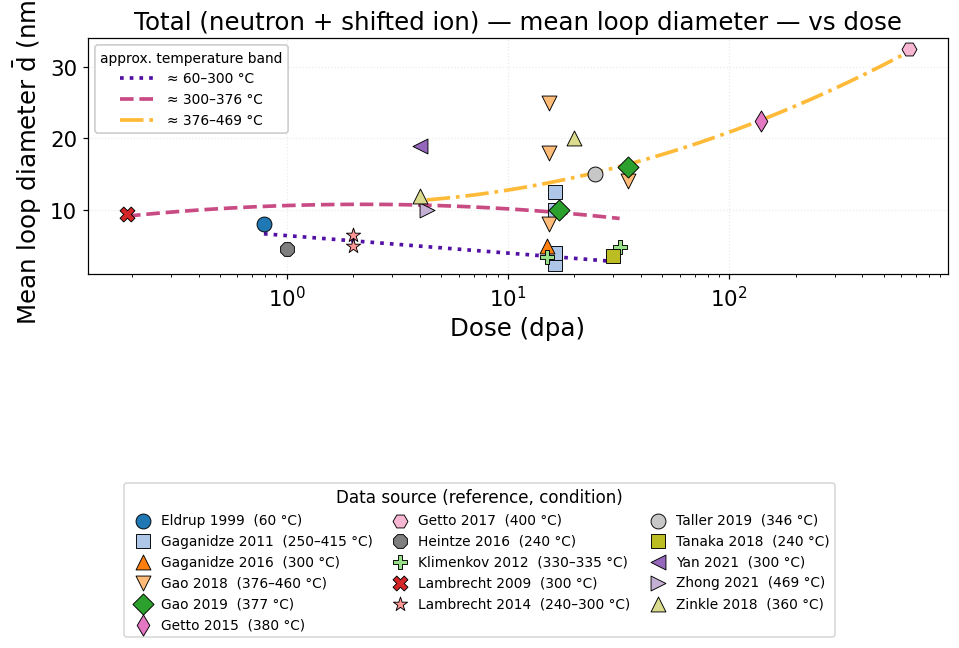

In [12]:
df = load_total("Loops_DenSize", val=15, ref=19, valparser=psize)
make_plots(df, r"Mean loop diameter $\bar d$ (nm)",
           "Total (neutron + shifted ion) — mean loop diameter",
           logy=False)
plt.show()

### (8c) Total — void / cavity number density
Neutron `Voids_DenSize` data plus the ion-irradiation cavity data shifted **−60 °C**, plotted with the same two scatter figures (vs temperature, vs dose).

Voids_DenSize: 8 neutron + 5 ion (shifted -60 °C) = 13 total points


Total (neutron + shifted ion) — void / cavity density: 13 points, 11 sources


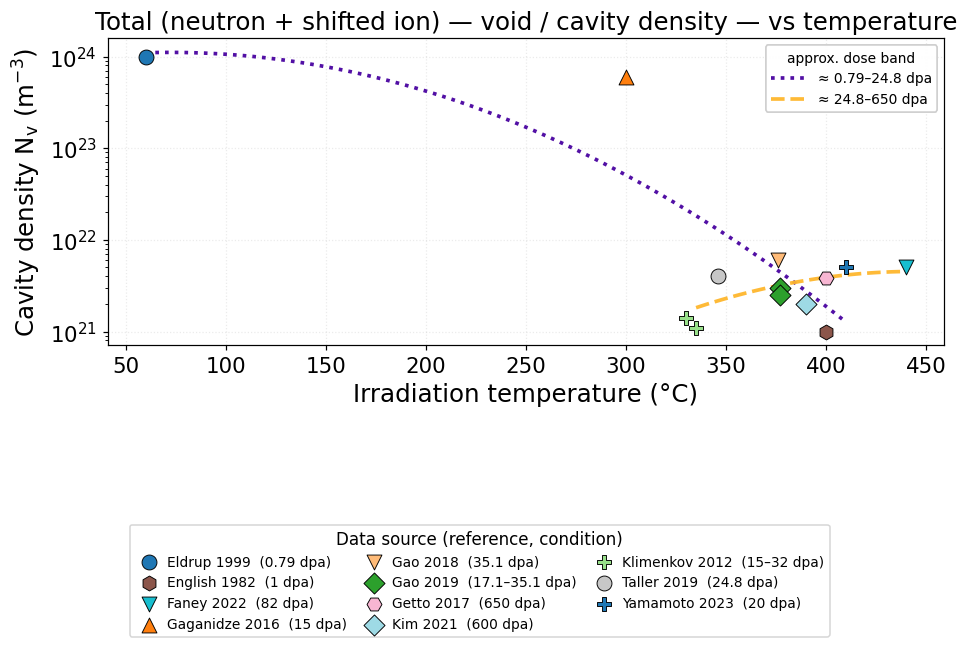

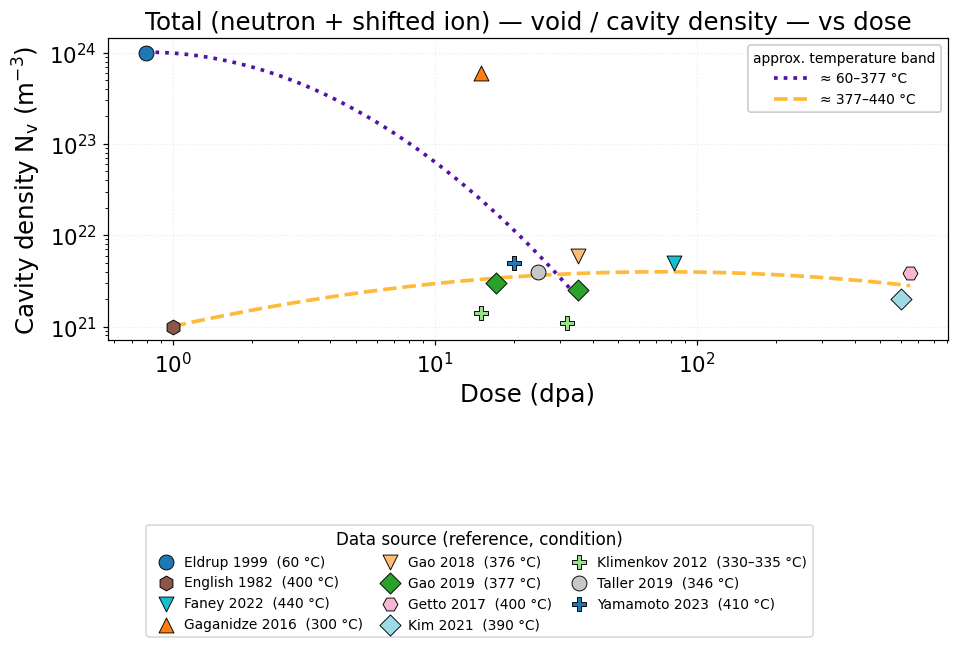

In [13]:
df = load_total("Voids_DenSize", val=10, ref=20, valparser=pdens)
make_plots(df, r"Cavity density $N_v$ (m$^{-3}$)",
           "Total (neutron + shifted ion) — void / cavity density",
           logy=True, dens_scale=1e22)
plt.show()